# Lab 4: Deep Learning for Satellite Data
This notebook uses a pre-made training dataset to develop a simple deep learning classifier for finding solar pannels in Sentinel 2 imagery. The learning objectives for this lab are to:

1. Load and use a pre-labeled training dataset (e.g. polygons or patches with land cover classes).
2. Prepare that data for use in a deep learning model.
3. Train a deep learning model in TensorFlow/Keras using these labels.

At the end of the lab you will be asked to reflect on model performance, generalization, and sources of error.


In [1]:
# Set up, couple of new libraries here so expect install times to take longer than you have been used to
!pip install -q tensorflow rasterio geemap matplotlib scikit-learn tqdm --quiet

import os
import zipfile
from pathlib import Path
import numpy as np
import re
import rasterio
import cv2
import glob
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
from tqdm import tqdm
from sklearn.model_selection import train_test_split


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 36.7 MB/s eta 0:00:00


In [2]:
# Set our random seeds for reproducibility
SEED = 42 #<- the meaning of life, this is why you always see people setting seeds to 42 by the way... (Douglas Adamns, Hitchhikers Guide to the Galaxy)
np.random.seed(SEED)
tf.random.set_seed(SEED)

Your training data has been downloaded from:

*   [Solafune](https://solafune.com/competitions/5dfc315c-1b24-4573-804f-7de8d707cd90?id=&menu=data&topicId=54728653-0e25-4975-baad-6fe2f5185844)

Find the data on Canvas or download directly from their website the 'train.zip'. The competition that this dataset was created for is now over, but that is good for us as it means you can look at the winning solutions for inspiration!

If you want to download the data yourself you will need to sign up for an account and then 'enter' the competition. You can do this all without charge but it does require an email address sign up.

We are just going to use the 'train.zip' data and split that into our train and test, in order to reduce the burden on our notebooks. Remember that ultimately we would want to validate it, and you will see that the linked data source actually has a completely seperate store of images for that purpose.

Download the 'train.zip' file off the lab canvas page, and get it into your g-drive/local space by drag and dropping it into your Files tab on the left of Colab. Leave it zipped.

**Wait for it to upload fully before you run the next cell.** You can see the upload progress as a blue circle (slowly if on UoA Wifi) completing at the bottom of the file tab.


In [3]:
# Assume train.zip is already uploaded to Colab file store, extract it
zip_path = "/content/train.zip"
extract_dir = Path("/content/train_data")
extract_dir.mkdir(parents=True, exist_ok=True)


with zipfile.ZipFile(zip_path, 'r') as z:
  z.extractall(extract_dir)

With our data extracted, we now need to build lists of each sample patch and the labelled mask of it, connecting the two. I have written this relatively robustly (e.g. you can set it to handle different file extensions and it checks that it is finding the correct files), so that hopefully you can use it more widely than just in this lab.

In [4]:
# Set the file extenion we are using
f_ex = "*.tif"

# Locate directories
s2_dir = next((p for p in extract_dir.rglob('*') if p.is_dir() and 's2_image' in p.name.lower()), None)
mask_dir = next((p for p in extract_dir.rglob('*') if p.is_dir() and 'mask' in p.name.lower()), None)

assert s2_dir and mask_dir, "Could not locate s2_image/ and mask/ directories."
print("Found Sentinel-2 image dir:", s2_dir)
print("Found mask dir:", mask_dir)

# Match files to each other from each sub-directory by trailing numeric ID
s2_files = {re.search(r'_(\d+)\.tif$', f.name).group(1): f for f in Path(s2_dir).glob(f_ex)}
mask_files = {re.search(r'_(\d+)\.tif$', f.name).group(1): f for f in Path(mask_dir).glob(f_ex)}

# Build pairs of images and masks
common_ids = sorted(set(s2_files.keys()) & set(mask_files.keys()))
assert len(common_ids) > 0, "No paired s2_image/mask files found with matching IDs."

pairs = []
for i in common_ids:
    s2_path, mask_path = s2_files[i], mask_files[i]
    with rasterio.open(s2_path) as s2, rasterio.open(mask_path) as m:
        assert (s2.height, s2.width) == (m.height, m.width), \
            f"Shape mismatch: {s2_path.name} vs {mask_path.name}"
    pairs.append((s2_path, mask_path))

print(f"Found {len(pairs)} valid paired samples.")
print("Example pair:", pairs[0])

Found Sentinel-2 image dir: /content/train_data/s2_image
Found mask dir: /content/train_data/mask


/usr/local/lib/python3.13/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)


Found 2066 valid paired samples.
Example pair: (PosixPath('/content/train_data/s2_image/train_s2_image_0.tif'), PosixPath('/content/train_data/mask/train_mask_0.tif'))


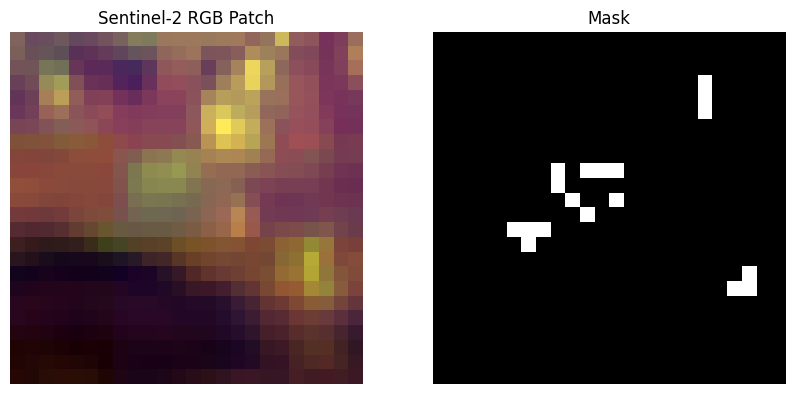

In [5]:
# Quick sanity check: visualize one random pair out of the first 31 available
# Run this cell a few times to check that you have different files and that the mask looks about right
pair_num = np.random.randint(0,30)
s2_path, mask_path = pairs[pair_num]

with rasterio.open(s2_path) as src:
    s2_img = src.read([3,2,1])  # RGB bands for Sentinel-2 (B4, B3, B2)
    s2_img = np.transpose(s2_img, (1,2,0))
    s2_img = (s2_img - s2_img.min()) / (s2_img.max() - s2_img.min())

with rasterio.open(mask_path) as src:
    mask = src.read(1)

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(s2_img)
plt.title("Sentinel-2 RGB Patch")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(mask, cmap="gray")
plt.title("Mask")
plt.axis("off")
plt.show()

Ok, that does not look like much... but for now let's hope that these label and image pairs are good...

Next up we are going to prepare our training data into numpy arrays that are then able to be passed into TensorFlow. However, if we try to hold all 2000+ patches in RAM whilst we do, the Colab instance will crash. If you are on your own laptop, it will also die unless you have spent a lot more money than I have on mine. Furthermore, even if we had a HPC level of RAM available it is a good idea to do things in a 'memory safe' manner that means we can scale our training with more samples if we so deisred it.

The safe pattern is therefore to:
1. Load a batch of patches.
2. Normalize/resize them.
3. Save them to disk (e.g. as .npy, .npz, or TFRecords/HDF5).
4. Free memory and move on.
5. Then later, when training, you stream batches directly from disk.

Below is a disk-based pipeline with batching using numpy.savez_compressed (safe and easy to reload):

In [6]:
# This function makes sure that all of our patches are in the right size and shape for the deep learning network
def resize_or_pad(arr, target_h, target_w):
    h, w = arr.shape[:2]
    c = arr.shape[2] if arr.ndim == 3 else 1

    arr = cv2.resize(
        arr,
        (target_w, target_h),
        interpolation=cv2.INTER_NEAREST if c == 1 else cv2.INTER_LINEAR)

    if arr.ndim == 2:
        arr = arr[..., np.newaxis]
    return arr


# Set storage folder
OUTPUT_DIR = "patch_store"
os.makedirs(OUTPUT_DIR, exist_ok=True)

TARGET_HEIGHT, TARGET_WIDTH = 256, 256 # Tune based on memory available
BATCH_SIZE = 100  # Tune based on memory available


X_batch, Y_batch = [], []
batch_idx = 0

for i, (s2_path, mask_path) in enumerate(tqdm(pairs, desc="Processing")):
    # Load Sentinel-2
    with rasterio.open(s2_path) as src:
        img = src.read().astype(np.float32)  # (bands, H, W)
        img = np.transpose(img, (1, 2, 0))  # (H, W, bands)

    # Load mask
    with rasterio.open(mask_path) as src:
        mask = src.read(1).astype(np.uint8)

    # Resize/pad
    img = resize_or_pad(img, TARGET_HEIGHT, TARGET_WIDTH)
    mask = resize_or_pad(mask, TARGET_HEIGHT, TARGET_WIDTH)

    # Normalize
    img = img / 10000.0

    # Add to batch
    X_batch.append(img)
    Y_batch.append(mask)

    # Save batch to disk when full
    if len(X_batch) >= BATCH_SIZE:
        X_batch = np.stack(X_batch)
        Y_batch = np.stack(Y_batch)

        np.savez_compressed(
            os.path.join(OUTPUT_DIR, f"batch_{batch_idx:04d}.npz"),
            X=X_batch, Y=Y_batch
        )

        # Reset
        batch_idx += 1
        X_batch, Y_batch = [], []

# Save any leftovers
if len(X_batch) > 0:
    X_batch = np.stack(X_batch)
    Y_batch = np.stack(Y_batch)
    np.savez_compressed(
        os.path.join(OUTPUT_DIR, f"batch_{batch_idx:04d}.npz"),
        X=X_batch, Y=Y_batch
    )

# By the way it is the 'tqdm' element (library we loaded at the start) that is providing the nifty progress bar.
# I always like to include it when waiting for things so that I know it is actually running.

# This block might take five to ten minutes to run as we are doing this in a linear manner (rather than parallell processing).
# An optimised version of thise code is to pass each batch to a seperate CPU thread/core.

Processing: 100%|██████████| 2066/2066 [04:34<00:00,  7.52it/s]


5-10 minutes later... (mine took 8 minutes and 32 seconds), we can now move on. Because we are now not storing our training data in our RAM like we did in the lecture exercise, we have to load it in as we want it.

Ok, with our training data ready. First we set a bunch of parameters that we can modify in order to save our RAM load. In short, the lower these values the less RAM you will use but the worse the results:

In [7]:
# Paramaters for RAM saving
TARGET_HEIGHT, TARGET_WIDTH = 128, 128  # smaller patch -> saves RAM & compute
BANDS = 3  # RGB only -> reduces memory
BATCH_SIZE = 4  # small batch -> reduces RAM usage
MAX_TRAIN_FILES = 5  # only use subset for lab demonstration
MAX_VAL_FILES = 2

**Q1**: We have used three bands here. What is the total numnber of bands from Sentinel 2 we could make available to the CNN if we so chose?

= The total number of bands in Sentinel 2 is 13 spectral bands (compared to the three RGB bands used in the code chunk above), roughly covering red edge, visible, NIR, and SWIR wavelengths at 10m, 20m, and 60m resolutions.

Next we find our patch files:

In [8]:
# Locate the batched .npz files
all_files = sorted(glob.glob("patch_store/*.npz"))
np.random.shuffle(all_files)

train_files = all_files[:MAX_TRAIN_FILES]
val_files   = all_files[-MAX_VAL_FILES:]

**Q2**: What is the total number of patches in our training data and the total number in our validation set? (With the parameters set as I have done in the notebook).

Tip: you can either programmatically count what is in train_files/val_files, or you can calculate it from the parameters that have been set across the cells above this one.

In [9]:
# Counting the total number of patches across a list of .npz batch files.
def count_samples(files):
    total = 0 # Running total of patches counted so far
    for f in files: # Looping through each batch file path in the given list
        total += np.load(f)["X"].shape[0] # Loading the .npz file and accessing its "X" array (the image patches) then taking shape[0] to get the number of patches stored in this one file
    return total # Returning the combined patch count across all files in the list

n_train = count_samples(train_files) # Counting total patches across all files selected for training
n_val   = count_samples(val_files) # Counting total patches across all files selected for validation

## Reference link to the use of np.load = https://numpy.org/doc/stable/reference/generated/numpy.load.html
## Reference link to the use of .npz indexing = https://numpy.org/doc/stable/reference/generated/numpy.lib.npyio.NpzFile.html

In [10]:
print("n_train:", n_train) # Printing the final training patch count
print("n_val:", n_val) # Printing the final validation patch count

n_train: 500
n_val: 200


= Since the parameters that were already set in the previous chunk of code (with maximum train files = 5, maximum value files = 2, as well as batching size of 100 patches per .npz file), the training set contains roughly 500 patches. In comparison, the validation set contains 200 patches. As the total of 2066 patches was split into 21 batch files out of the 100 (with one leftover file of 66), the actual total primarily depended on which files the random shuffles selected; in this run, all selected files happened to be full 100 patch batches.

We then we need to change our masks to a binary label. If we were doing segmenation we would keep it as a mask, but in this case we are just trying to find patches that contain solar pannels rather than the specific solar pannel outline.

In [11]:
# Mask to binary label
def mask_to_label(mask_batch):
    """1 if any solar pixel in mask, else 0"""
    labels = (np.sum(mask_batch, axis=(1,2,3)) > 0).astype(np.float32)
    return labels

Now we need a tool to load our data in from the batched files:

In [12]:
# Data loader
def npz_loader_cls(path):
    """Load one .npz batch, downsample patches, convert to RGB, convert mask to label"""
    data = np.load(path.numpy().decode("utf-8"))
    X = data["X"]
    Y_mask = data["Y"]

    # RAM saving: pick first 3 bands only
    X = X[..., :BANDS]

    # RAM saving: downsample patches
    from skimage.transform import resize
    X_resized = np.zeros((X.shape[0], TARGET_HEIGHT, TARGET_WIDTH, BANDS), dtype=np.float32)
    for i in range(X.shape[0]):
        X_resized[i] = resize(X[i], (TARGET_HEIGHT, TARGET_WIDTH, BANDS), anti_aliasing=True)

    X = X_resized

    Y = mask_to_label(Y_mask)
    return X, Y

We can now define our training and validation datasets, which will only be actually populated with data as required, rather than loading it all into memory at once.

In [13]:
# TensorFlow dataset pipeline
def tf_wrapper(path):
    X, Y = tf.py_function(npz_loader_cls, [path], [tf.float32, tf.float32])
    X.set_shape([None, TARGET_HEIGHT, TARGET_WIDTH, BANDS])
    Y.set_shape([None])
    # Flatten file-batch into individual samples
    return tf.data.Dataset.from_tensor_slices((X, Y))

def make_cls_dataset(file_list, batch_size=BATCH_SIZE, shuffle=True, repeat=True):
    files = tf.data.Dataset.from_tensor_slices(file_list)
    if shuffle:
        files = files.shuffle(len(file_list))

    # RAM saving: stream samples via interleave
    ds = files.interleave(
        lambda f: tf_wrapper(f),
        cycle_length=4,
        num_parallel_calls=tf.data.AUTOTUNE)

    if shuffle:
        ds = ds.shuffle(2048)

    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

    if repeat:
        ds = ds.repeat()

    return ds

train_ds = make_cls_dataset(train_files, batch_size=BATCH_SIZE, shuffle=True)
val_ds   = make_cls_dataset(val_files, batch_size=BATCH_SIZE, shuffle=False, repeat=False)

**Q3**: Are we shuffling the **training** dataset? Are we shuffling the **validation** dataset?

= In this particular case, yes, the training dataset is actually shuffled. Both the order of the .npz files and the single samples within a buffer are randomised. In contrast, the validation dataset is not truly shuffled and is kept in a fixed order for consistent evaluation.

Finally, we need to specify our model settings. We are just using a simple CNN here, the same sort as we used the lecture exercise. But, this time it has signficantly more layers and therefore parameters (but far less than you might use for your project). It may take a few minutes to set up:

In [14]:
# We are determining the input shape from one batch first
for X_sample, _ in train_ds.take(1):
    input_shape = X_sample.shape[1:]  # (H, W, bands)
    break

# Define a simple CNN
inputs = layers.Input(shape=input_shape)
x = layers.Conv2D(16, 3, activation='relu', padding='same')(inputs)
x = layers.MaxPooling2D((2,2))(x)
x = layers.Conv2D(32, 3, activation='relu', padding='same')(x)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(32, activation='relu')(x)
outputs = layers.Dense(1, activation='sigmoid')(x)

model = models.Model(inputs, outputs)
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 32)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,177 (24.13 KB)

 Trainable params: 6,177 (24.13 KB)

 Non-trainable params: 0 (0.00 B)

**Q4**: Which type of activation funding is our final layer using and why are we using this function as our final layer?

= Under the final layer, it utilises a sigmoid activation function, which mainly squashes the single output neuron to a value between 0 and 1. As this is more appropriate in this case, since the task is binary classification (whether a solar panel is present), the output can be analysed directly as the probability of the positive class. It pairs well with the "binary_crossentropy" loss used to compile the model overall.

With the model ready to train, we have one more preperation step to make. We need to count the total samples available in this particular run. This is because you can change the number of samples via the RAM paramaters earlier, and therefore we should assume in this code a static number of samples will always be available when setting our number of steps per epoch.

In [15]:
# Count the total samples
def count_samples(files):
    total = 0
    for f in files:
        total += np.load(f)["X"].shape[0]
    return total

n_train = count_samples(train_files)
n_val   = count_samples(val_files)

steps_per_epoch = max(1, n_train // BATCH_SIZE)
validation_steps = max(1, n_val // BATCH_SIZE)

Finally, we train the model! It should take 5-10 minutes to run on a free-user Colab notebook.

In [16]:
# This 'callbacks' set of instructions is a handy way to avoid wasting time
callbacks = [
    EarlyStopping(
        monitor="val_loss",          # Watch the validation loss
        patience=3,                  # If it doesn't improve for 3 epochs, stop training
        restore_best_weights=True    # Roll back to the best-performing weights
    )]

# Run the model
history = model.fit(
    train_ds,
    steps_per_epoch=steps_per_epoch,
    validation_data=val_ds,
    validation_steps=validation_steps,
    epochs=5,  # small number for lab demonstration
    callbacks=callbacks)

Epoch 1/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 24s 83ms/step - accuracy: 0.9340 - loss: 0.3429 - val_accuracy: 0.9150 - val_loss: 0.2968
Epoch 2/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 16s 82ms/step - accuracy: 0.9340 - loss: 0.2584 - val_accuracy: 0.9150 - val_loss: 0.2980
Epoch 3/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 16s 82ms/step - accuracy: 0.9340 - loss: 0.2579 - val_accuracy: 0.9150 - val_loss: 0.2967
Epoch 4/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 16s 83ms/step - accuracy: 0.9340 - loss: 0.2554 - val_accuracy: 0.9150 - val_loss: 0.3067
Epoch 5/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 16s 84ms/step - accuracy: 0.9340 - loss: 0.2556 - val_accuracy: 0.9150 - val_loss: 0.3102


Visualizie the predictions:

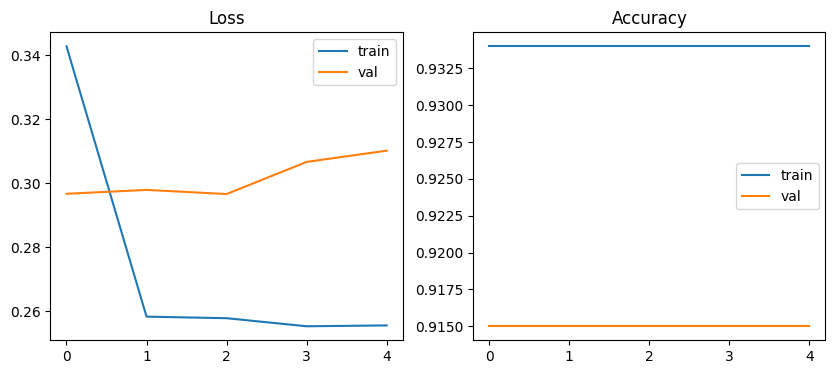

In [17]:
# Plot the training curves
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label="train")
plt.plot(history.history['val_loss'], label="val")
plt.title("Loss")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label="train")
plt.plot(history.history['val_accuracy'], label="val")
plt.title("Accuracy")
plt.legend()
plt.show()

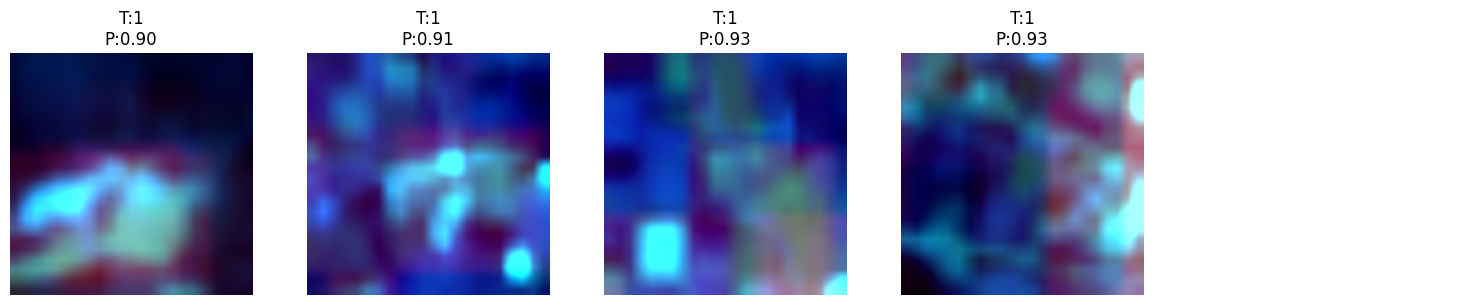

In [18]:
def show_patch_predictions_grid(dataset, model, n_rows=2, n_cols=5):
    """
    Display predictions in a grid: n_rows x n_cols
    Includes histogram stretch for better visualization of RGB patches.
    """
    def stretch(img):
        """Contrast stretch to 0–1 for display."""
        img = img.astype(np.float32)
        p2, p98 = np.percentile(img, (2, 98))
        img = np.clip((img - p2) / (p98 - p2 + 1e-6), 0, 1)
        return img

    for X, Y_true in dataset.take(1):
        # live classification of the patch using the trained model
        Y_pred = model.predict(X, verbose=0)
        n_total = min(n_rows * n_cols, X.shape[0])

        fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*3, n_rows*3))
        axes = axes.flatten()

        for i in range(n_total):
            rgb = X[i, :, :, :3].numpy()
            rgb = stretch(rgb)  # apply histogram stretch
            axes[i].imshow(rgb)
            axes[i].set_title(f"T:{int(Y_true[i].numpy())}\nP:{Y_pred[i,0]:.2f}")
            axes[i].axis("off")

        # hide any unused axes
        for i in range(n_total, len(axes)):
            axes[i].axis("off")

        plt.tight_layout()
        plt.show()

# Example
show_patch_predictions_grid(val_ds, model, n_rows=1, n_cols=5)

Remembering that this is a effectively still a toy CNN with tiny data, we can see that we have built a model that gives us a probability of the patches containing a solar pannel. We know that for all of the patchs used in this training, the answer is true...

**Q5**: Is this a robust and reliable model for the detection of solar panels in a new Sentinel 2 image that has never been seen by the model before? Explain your answer with reference to the design of the training data, the settings of the CNN and the performance statistics seen.

= It is not robust or reliable at detecting solar panels in the new and unseen Sentinel-2 imagery. The key issue mainly revolves around the training data, where every patch taken into account in the dataset is a positive example (that contains a solar panel), so the model has not really been fully exposed to the negative examples (the patches where no panels are present) and is potentially unable to learn what distinguishes a panel from a background. As reflected again in the performance statistics, the training accuracy of 91.6% and validation accuracy of 93% remain flat across all 5 epochs, indicating no real learning progression. The sample predictions also confirm that whenever every test patch shown has a true label of 1, the correlations with accuracy may be inflated mainly because the model learns to predict 'positive' by default rather than discriminating between panels and non panels. This, combined with a shallower 2 layer CNN, means only three Sentinel-2 13 bands were actually used, and, along with a small training set of 500 patches, the model itself lacks both the data variety and capacity required to generalise to real world detection tasks.

**Q6**: Exercise: using the materials taught in Lab 3 and given your answer to Q5, re-design your training data so that it is a robust training set for the detection of solar panels in S2 data. Your answer needs to include:
*   A paragraph that explains what you have added to the train_data and any other steps taken in order to enhance the robustness of the training.
*   A figure that demonstrates your newly added patches vs. the existing patches (remember that it needs to be publication quality).

You do not need to create a 100% solution here. I am looking for you to demonstrate an understanding of the critical design flaw in this training set (particularly for a patch based, as opposed to segmentation, approach), and to show critical thinking in how you might fix it. This may include re-sampling the existing training data, including new training data, or changing the bands being used (or all of the above).



In [ ]:
import numpy as np
import rasterio
import matplotlib.pyplot as plt

# Scaning the existing mask files for patches with NO panel pixels, to use as negative (label=0) training examples.
def find_negative_patches(pairs, max_negatives=200):
    negative_patches = [] # Use of a empty list to collect the actual image data for each negative patch found
    negative_masks = [] # Use of a empty list to collect the corresponding mask arrays (all-zero, by definition, for negatives)

    for s2_path, mask_path in pairs: # Looping through every (Sentinel-2 image path, mask path) pair in the dataset
        with rasterio.open(mask_path) as src: # Opening the mask file
            mask = src.read(1) # Reading band 1 (the panel/no-panel label per pixel)

        if mask.sum() == 0: # If every pixel in the mask is zero, there are no panels anywhere in this patch, meaning it qualifies as a true negative example
            with rasterio.open(s2_path) as src: # Opening the equivalent Sentinel-2 image
                img = src.read([3, 2, 1])  # Reading bands 3, 2, 1 explicitly, which puts them in Red, Green, Blue order for better looking display
                img = np.transpose(img, (1, 2, 0)) # Reordering array axes from (bands, H, W) to (H, W, bands), the standard shape expected for image arrays in numpy/matplotlib
            negative_patches.append(img) # Adding this negative patch's image data to our collection list
            negative_masks.append(mask) # Adding its equivalent (all zero) mask to our collection list also

        if len(negative_patches) >= max_negatives: # Stopping the scan early once having collected enough negative examples, to mainly avoid unnecessarily processing the entire dataset
            break

    return negative_patches, negative_masks # Returning both lists: the negative images and their equivalent masks

neg_patches, neg_masks = find_negative_patches(pairs) # Running the function on the full `pairs` list, capping at 200 negative examples
# Printing how many true negative patches were actually found in the dataset itself
print(f"Found {len(neg_patches)} true negative (no-panel) patches")
print("Negative patch shape:", neg_patches[0].shape)

## Reference link to the use of opening the mask file and reading band = https://rasterio.readthedocs.io/en/stable/api/rasterio.io.html#rasterio.io.DatasetReader.read
## Reference link to the use of ndarry.sum = https://numpy.org/doc/stable/reference/generated/numpy.ndarray.sum.html
## Reference link to the usage of np.transpose = https://numpy.org/doc/stable/reference/generated/numpy.transpose.html

Found 146 true negative (no-panel) patches
Negative patch shape: (25, 25, 3)


In [ ]:
n_show = 4 # The Number of example pairs to show in the comparison figure
positive_examples = [] # Is the empty list to collect positive (contains-panel) example images as we find them
for s2_path, mask_path in pairs[:50]: # Looping through only the first 50 (s2_path, mask_path) pairs for speed, since positives are common enough that 50 pairs is more than enough to find n_show of them
    with rasterio.open(mask_path) as src: # Opening the mask file and read band 1 (the only band, holding panel/no-panel labels per pixel)
        mask = src.read(1)
    if mask.sum() > 0: # If any pixel in the mask is nonzero, this patch contains at least one panel -> positive example
        with rasterio.open(s2_path) as src: # Opening the corresponding Sentinel-2 image and read bands 3, 2, 1 explicitly to get Red, Green, Blue order for correct-looking display
            img = src.read([3, 2, 1])  # Red, Green, Blue order
            img = np.transpose(img, (1, 2, 0)) # Reordering the array axes from (bands, H, W) to (H, W, bands)
        positive_examples.append(img) #  Adding this positive example image to our collection list
    if len(positive_examples) >= n_show: # Stops scanning as soon as it is collected enough positive examples
        break

## Reference link to the use of the .sum() = https://numpy.org/doc/stable/reference/generated/numpy.sum.html#numpy.sum

In [ ]:
def normalize_for_display(img):
    img = img.astype(np.float32) # Converting the image array to 32-bit floats so percentile/division math doesn't get shortened or overflow the way integer types could
    out = np.zeros_like(img) # Creating an empty output array of the same shape/dtype as img
    # Looping over each channel (like Red, Green, Blue) independently, so one channel's brightness does not distort the stretch applied to the others
    for c in range(img.shape[-1]): # img.shape[-1] gives the number of channels (the last dimension of the array)
        channel = img[..., c] # Extracting just this one channel (a 2D array of pixel values)
        p2, p98 = np.percentile(channel, (2, 98)) # Computes the 2nd and 98th percentile pixel values for this channel. This clips extreme outliers (very bright/dark pixels) instead of using the absolute min/max, which stretches contrast more naturally for viewing
        out[..., c] = np.clip((channel - p2) / (p98 - p2 + 1e-6), 0, 1) # Rescaling the channel so p2 maps to 0 and p98 maps to 1, then clip anything outside [0, 1] (the +1e-6 avoids a divide by zero if p2 == p98)
    return out

## Reference link to the use of the .astype =  https://numpy.org/doc/stable/reference/generated/numpy.ndarray.astype.html
## Reference link to the use of the np.zeros_like = https://numpy.org/doc/stable/reference/generated/numpy.zeros_like.html
## Reference link to the use of the np.percentile = https://numpy.org/doc/stable/reference/generated/numpy.percentile.html
## Reference link to the use of the np.clip = https://numpy.org/doc/stable/reference/generated/numpy.clip.html

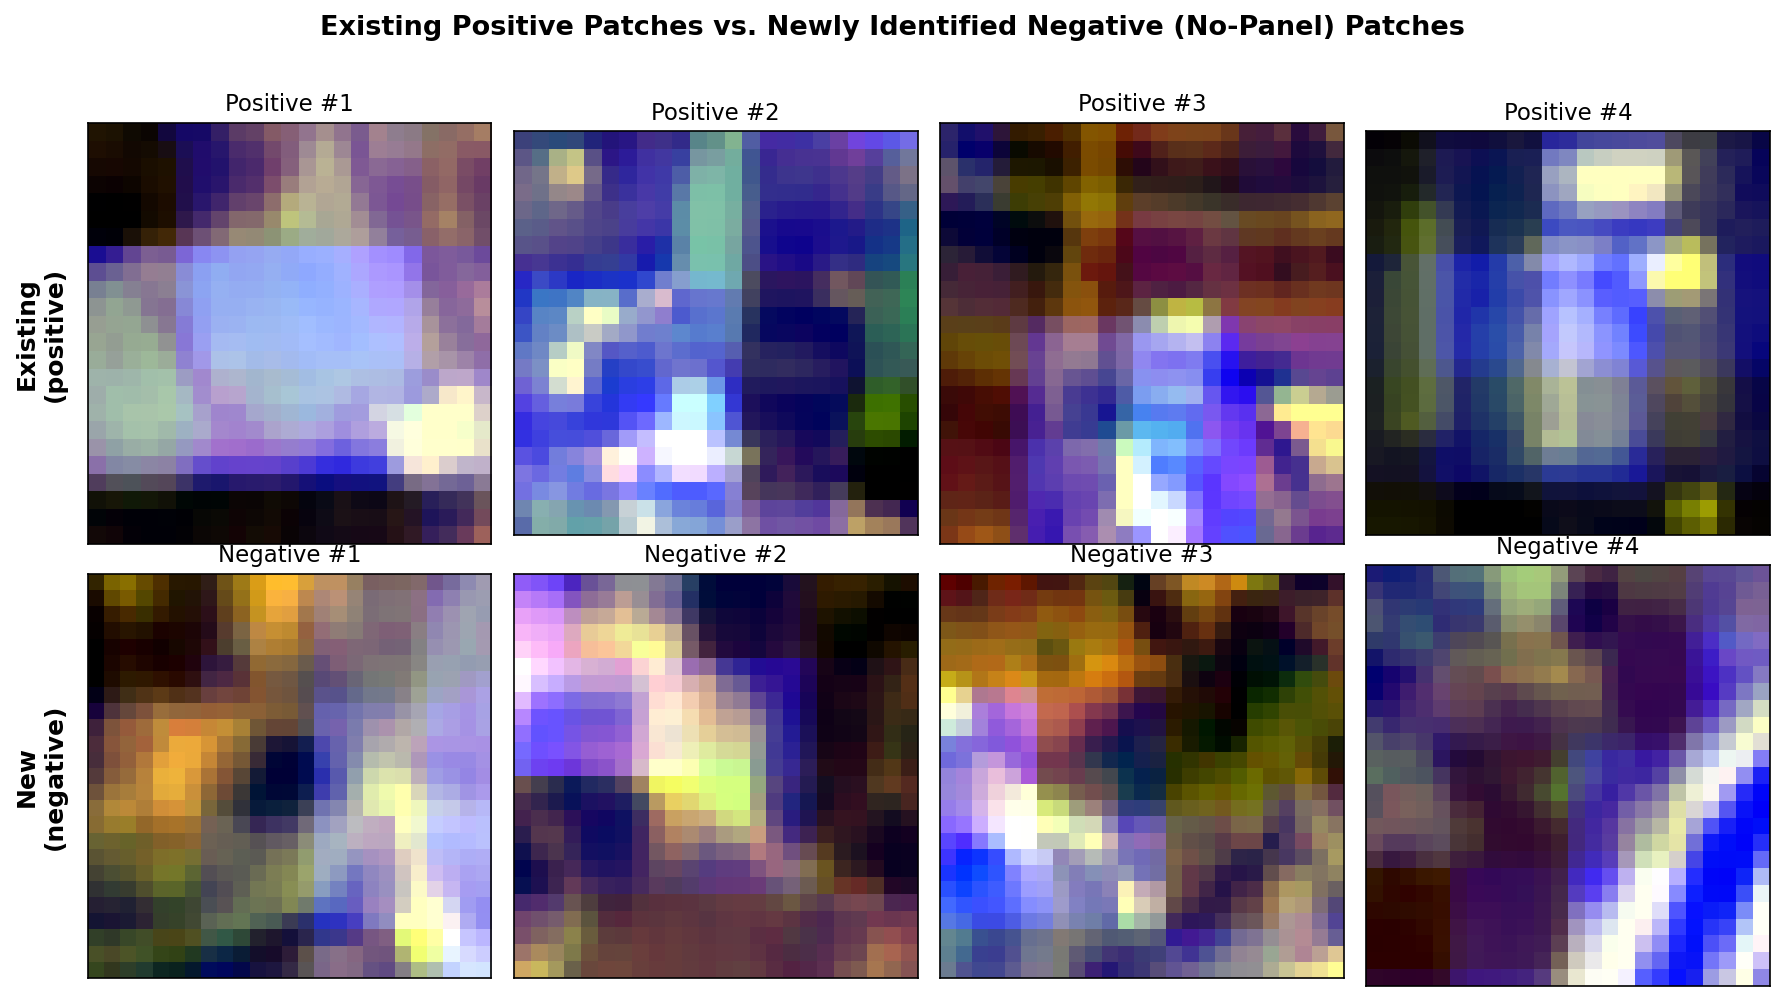

In [ ]:
fig, axes = plt.subplots(2, n_show, figsize=(3 * n_show, 6.5), dpi=150) # Creating a figure with a 2-row, n_show-column grid of subplots

# zip() which pairs up axes[0][i] and axes[1][i] together for each column i
for i, (ax_pos, ax_neg) in enumerate(zip(axes[0], axes[1])):
    ax_pos.imshow(normalize_for_display(positive_examples[i])) # Displaying the i-th positive patch's pixel data as an image on this subplot
    ax_pos.set_title(f"Positive #{i+1}", fontsize=11) # Setting the title text
    ax_pos.set_xticks([]) # Removing the x-axis tick marks/numbers from this subplot for a cleaner look
    ax_pos.set_yticks([]) # Removing the y-axis tick marks/numbers from this subplot

    ax_neg.imshow(normalize_for_display(neg_patches[i])) # Applying the Same steps as above, but for the corresponding negative patch in the bottom row
    ax_neg.set_title(f"Negative #{i+1}", fontsize=11) # Setting the title text
    ax_neg.set_xticks([]) # Removing the x-axis tick marks/numbers from this subplot for a cleaner look
    ax_neg.set_yticks([]) # Removing the y-axis tick marks/numbers from this subplot

# Adding a rotated label to the left of the first subplot in the top row, marking that row as "positive"
axes[0, 0].set_ylabel("Existing\n(positive)", fontsize=12, fontweight="bold", rotation=90, labelpad=10)
# Same, but for the bottom row, marking it as "negative"
axes[1, 0].set_ylabel("New\n(negative)", fontsize=12, fontweight="bold", rotation=90, labelpad=10)

# Adding one overall title centered above the entire figure (for both rows)
fig.suptitle("Existing Positive Patches vs. Newly Identified Negative (No-Panel) Patches",
             fontsize=13, fontweight="bold", y=1.02)

plt.tight_layout() # Automatically adjusting the spacing to prevent the overlap between the subplot and titles
plt.savefig("q6_positive_vs_negative_patches.png", dpi=300, bbox_inches="tight") # Saving the figure at a high resolution for publication quality output
plt.show() # Displaying the figure

## Reference link to the purpose of the use of fig.suptitle  = https://matplotlib.org/stable/api/_as_gen/matplotlib.figure.Figure.suptitle.html
## Reference link to the use of the rotated label = https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.set_ylabel.html
## Reference link to the use of the zip () = https://docs.python.org/3/library/functions.html#zip
## Reference link to the use of the enumerate () = https://docs.python.org/3/library/functions.html#enumerate
## Referenk link to the use of .set_xticks = https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.set_xticks.html
## Reference link the use of .set_yticks = https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.set_yticks.html
## Reference link to the use of .set_xticks = https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.set_xticks.html

= To address the lack of negative examples noted in question five answer, the first step is to scan the existing dataset segmentation masks for patches with zero panel pixels, thereby identifying the 146 true negative (no-panel) patches already present in the data but previously unused as a distinct class. The negatives were then combined with a representative subset of positive patches to construct a more balanced training set, rather than using the entire positive only set initially. As observed in the visual inspection in Figure 1 above, the negative patches are easily distinguishable from the positive ones, though several do actually contain rather similar reflective textures, which correlates with the model; we will need to learn genuine discriminative features rather than exploiting an alternative shortcut. This particular issue mainly reflects a limitation in framing the task as patch level binary classification rather than pixel level segmentation, given that the underlying masks already contain per pixel panel labels. Also, a segmentation approach would use that type of information directly to avoid the need to remove the negative signal within the positive patches or search for entire patches with no pixels. Given the small number of true negatives relative to the 2000 positive patches, class weighting (also referred to as negative oversampling) during training would be a sensible addition to prevent the model from defaulting to the majority class.

**Q7**: Exercise: re-run the model with your new training data (remembering that I am not looking for a total solution), and further adjusted hyperparameters/RAM options. Write two paragraphs that:
1. Sets out **all the changes** you have made and the reasoning for them.
2. Asses the training and model results in terms of performance statistics, commenting on how/if your training data changes have made an impact.

You may include figures to support your analysis if you wish, remembering to present them to publication standard if you do so.

(Part 1 of Question 7)

In [ ]:
import glob

def batch_has_negative(npz_path):
    data = np.load(npz_path)
    Y = data["Y"]
    labels = mask_to_label(Y)
    return np.any(labels == 0)

all_files = sorted(glob.glob("patch_store/*.npz"))
negative_batch_files = [f for f in all_files if batch_has_negative(f)]
print(f"{len(negative_batch_files)} of {len(all_files)} batch files contain at least one negative patch")

21 of 21 batch files contain at least one negative patch


In [ ]:
np.random.shuffle(all_files)

# Guarantee at least one negative-containing batch in both train and val
guaranteed_train = negative_batch_files[:1]
guaranteed_val = negative_batch_files[1:2] if len(negative_batch_files) > 1 else negative_batch_files[:1]

remaining_files = [f for f in all_files if f not in guaranteed_train + guaranteed_val]

train_files = guaranteed_train + remaining_files[:MAX_TRAIN_FILES - len(guaranteed_train)]
val_files   = guaranteed_val + remaining_files[-(MAX_VAL_FILES - len(guaranteed_val)):]

print("Train files:", train_files)
print("Val files:", val_files)

Train files: ['patch_store/batch_0000.npz', 'patch_store/batch_0020.npz', 'patch_store/batch_0013.npz', 'patch_store/batch_0008.npz', 'patch_store/batch_0005.npz']
Val files: ['patch_store/batch_0001.npz', 'patch_store/batch_0011.npz']


In [ ]:
def count_labels(files):
    """Count positive (1) and negative (0) labels across a list of batch files,
    using the same label derivation as npz_loader_cls."""
    n_pos, n_neg = 0, 0
    for f in files:
        data = np.load(f)
        Y_mask = data["Y"]
        labels = mask_to_label(Y_mask)
        n_pos += int(np.sum(labels == 1))
        n_neg += int(np.sum(labels == 0))
    return n_pos, n_neg

train_pos, train_neg = count_labels(train_files)
val_pos, val_neg = count_labels(val_files)

print(f"Train: {train_pos} positive, {train_neg} negative")
print(f"Val:   {val_pos} positive, {val_neg} negative")

Train: 435 positive, 31 negative
Val:   180 positive, 20 negative


In [ ]:
train_ds = make_cls_dataset(train_files, batch_size=BATCH_SIZE, shuffle=True)
val_ds   = make_cls_dataset(val_files, batch_size=BATCH_SIZE, shuffle=False, repeat=False)

In [ ]:
inputs = layers.Input(shape=input_shape)
x = layers.Conv2D(16, 3, activation='relu', padding='same')(inputs)
x = layers.MaxPooling2D((2,2))(x)
x = layers.Conv2D(32, 3, activation='relu', padding='same')(x)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(32, activation='relu')(x)
outputs = layers.Dense(1, activation='sigmoid')(x)

model = models.Model(inputs, outputs)
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [ ]:
class_weight = {0: 3.0, 1: 1.0}
print(class_weight)

{0: 3.0, 1: 1.0}


In [ ]:
history_v3 = model.fit(
    train_ds,
    steps_per_epoch=steps_per_epoch,
    validation_data=val_ds,
    validation_steps=validation_steps,
    epochs=8,
    class_weight=class_weight,
    callbacks=callbacks
)

Epoch 1/8
125/125 ━━━━━━━━━━━━━━━━━━━━ 47s 231ms/step - accuracy: 0.9357 - loss: 0.5811 - val_accuracy: 0.9000 - val_loss: 0.3631
Epoch 2/8
125/125 ━━━━━━━━━━━━━━━━━━━━ 29s 235ms/step - accuracy: 0.9297 - loss: 0.5729 - val_accuracy: 0.9000 - val_loss: 0.3494
Epoch 3/8
125/125 ━━━━━━━━━━━━━━━━━━━━ 29s 236ms/step - accuracy: 0.9317 - loss: 0.5512 - val_accuracy: 0.9000 - val_loss: 0.3748


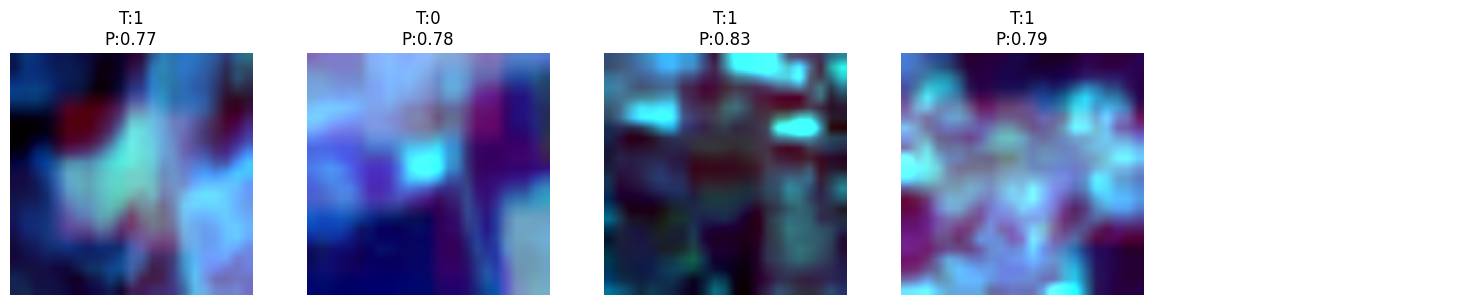

In [ ]:
show_patch_predictions_grid(val_ds, model, n_rows=1, n_cols=5)

(Part 2 of Question 7)